## Clustering

In [2]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

# import data
from sklearn.datasets import make_blobs

# import clustering algs
from sklearn.cluster import KMeans, MeanShift, DBSCAN
from sklearn.model_selection import train_test_split

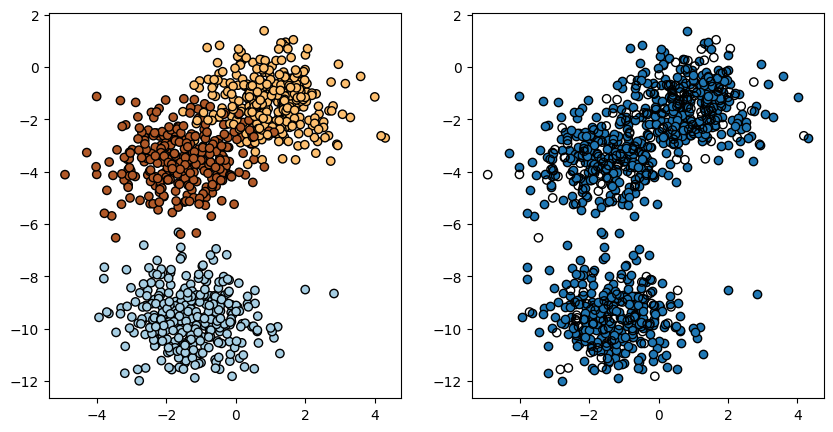

In [3]:
 X , y = make_blobs(n_samples = 1000, n_features = 2, random_state=2) #, centers = clusters

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2)

_, axes = plt.subplots(1, 2, figsize = (10,5))
axes[0].scatter( X [:, 0], X [:, 1], c = y, edgecolors ='k', cmap = 'Paired')
axes[1].scatter( X_train [:, 0], X_train [:, 1], edgecolors ='k')
axes[1].scatter( X_test [:, 0], X_test [:, 1], edgecolors ='k', facecolors='none')
plt.show()

In [ ]:
# import decision boundaries function
import sys
sys.path.append("/content/drive/MyDrive/content/colab/machine_learning")
from Tools.utils import plot_decision_boundaries


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


NameError: name 'plot_decision_boundaries' is not defined

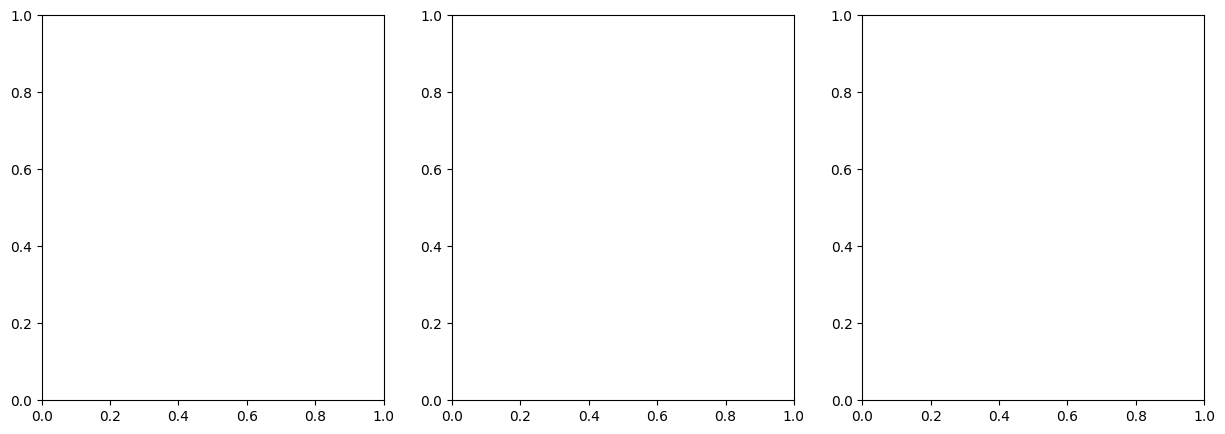

In [13]:
models = [ KMeans(n_clusters= 3 ) , MeanShift( bandwidth=1.5 ) , DBSCAN(eps = 1.5, min_samples= 5) ]

names = ["K=3 Means", "MeanShift", "DBSCAN (eps=1.5, ms=5)"]

#vamos a graficar con fronteras de decision
_, axes = plt.subplots(1, len(names), figsize = (5*len(names),5))
preds = {};

# fit the model
for i, (model, name) in enumerate(zip(models, names)) :
    # Instance and train
    model.fit(X_train)
    if (isinstance(model, DBSCAN)):
      preds[name] = model.fit_predict(X_test)
    else:
      preds[name] = model.predict(X_test)

    # Plot decision boundaries
    plot_decision_boundaries(model, X_test, y_test, n_points = 200, ax = axes[i])
    print("Model: {0} trained completed!".format(name))

    # Predictions on train and test sets
    _
    _

    # Plot everything
    _

plt.show()

## Metrics

The metrics module [Metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) de sklearn

In [18]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score

In [19]:
## Scores for training data

for name in names : #no se requiere enumerate porque no vamos a usar plots
  print ("########----- Results for {0} -----########".format(name))
  ari = adjusted_rand_score( y_test , preds[name] ) #se requiere pseudolabels distancia inter e interaclusters
  ami = adjusted_mutual_info_score( y_test, preds[name] ) #se requiere pseudolabels distancia inter(se separen) e interaclusters(este bien integradas la muestras)
  sil = silhouette_score(X_test, preds[name]) #no se requiere pseudolabels

  ##--------------
  print("-- ARI --\t -- AMI --\t -- SIL --\t --")
  print("  {0:.3f}  \t   {1:.3f}  \t   {2:.3f}  \t".format(ari, ami, sil))

########----- Results for K=3 Means -----########
-- ARI --	 -- AMI --	 -- SIL --	 --
  0.906  	   0.890  	   0.578  	
########----- Results for MeanShift -----########


KeyError: 'MeanShift'

In [ ]:
## Scores for test data

for i, key in enumerate(predsT.keys()):
  print ("########----- Results for {0} -----########".format( _ ))
  ari = adjusted_rand_score( _ , _ )
  ami = adjusted_mutual_info_score( _ , _ )
  ##--------------
  print("-- ARI --\t -- AMI --\t --")
  print("  {0:.3f}  \t   {1:.3f}  \t   {2:.3f}  \t".format(ari, ami))

## In real data

In [20]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

# import data
from sklearn.datasets import load_digits

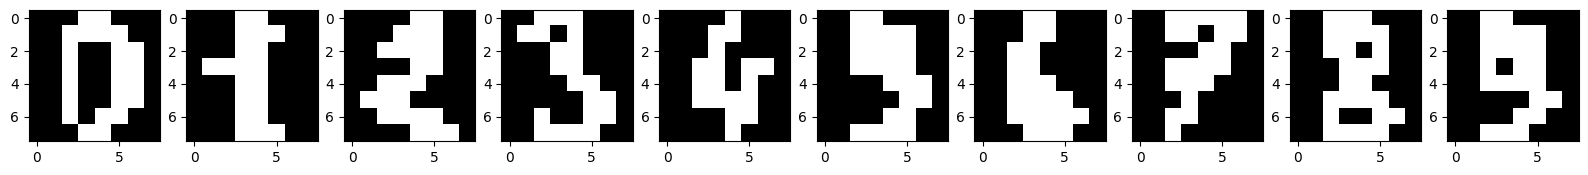

In [21]:
digits = load_digits()
images = (digits.images > 6) * 1.0

_, axes = plt.subplots(1,10, figsize=(20,4))
for i, ax in enumerate(axes):
  ax.imshow(images[i].reshape(8,8), cmap="gray")

plt.show()